## Phase 1: Sea Level Anomaly (SLA) Data Analysis & Preprocessing

# 1. Load and Inspect Dataset

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [2]:
# Load the dataset (update path as needed)
ds = xr.open_dataset(r"C:\Users\Shyam\Downloads\dt_global_satellite_sla_199302_202305.nc")
ds

<xarray.Dataset> Size: 2GB
Dimensions:         (time: 364, bnds: 2, longitude: 1440, latitude: 720)
Coordinates:
  * time            (time) datetime64[ns] 3kB 1993-02-15 ... 2023-05-15
  * longitude       (longitude) float32 6kB 0.125 0.375 0.625 ... 359.6 359.9
  * latitude        (latitude) float32 3kB -89.88 -89.62 -89.38 ... 89.62 89.88
Dimensions without coordinates: bnds
Data variables:
    time_bnds       (time, bnds) datetime64[ns] 6kB ...
    longitude_bnds  (longitude, bnds) float32 12kB ...
    latitude_bnds   (latitude, bnds) float32 6kB ...
    crs             int32 4B ...
    sla             (time, latitude, longitude) float32 2GB ...
Attributes: (12/45)
    CDI:                             Climate Data Interface version 2.0.4 (ht...
    Conventions:                     CF-1.6
    source:                          Altimetry measurements
    institution:                     CNES, CLS
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    cdm_data_type:                   Grid
    ...                              ...
    time_coverage_duration:          P1M
    time_coverage_end:               1993-02-28T00:00:00Z
    time_coverage_resolution:        P1M
    time_coverage_start:             1993-02-01T00:00:00Z
    title:                           DT merged two-satellite Global Ocean L4 ...
    CDO:                             Climate Data Operators version 2.0.4 (ht...

In [3]:
# 2. Select SLA Variable and Region
# ----------------------------------------------

sla = ds['sla']  # Replace with actual variable name
region = sla.sel(latitude=slice(10, 20), longitude=slice(65, 85))

In [4]:
# 3. Interpolate Missing Data
# ----------------------------------------------
sla_interp = region.interpolate_na(dim='time', method='linear', limit=2)


In [5]:
# 4. Temporal Analysis
# ----------------------------------------------
# Compute regional mean
region_mean = sla_interp.mean(dim=['latitude', 'longitude'], skipna=True)
region_mean_df = region_mean.to_dataframe().dropna().reset_index()


C:\Users\Shyam\AppData\Local\Temp\ipykernel_21584\291346525.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc = 'upper left')


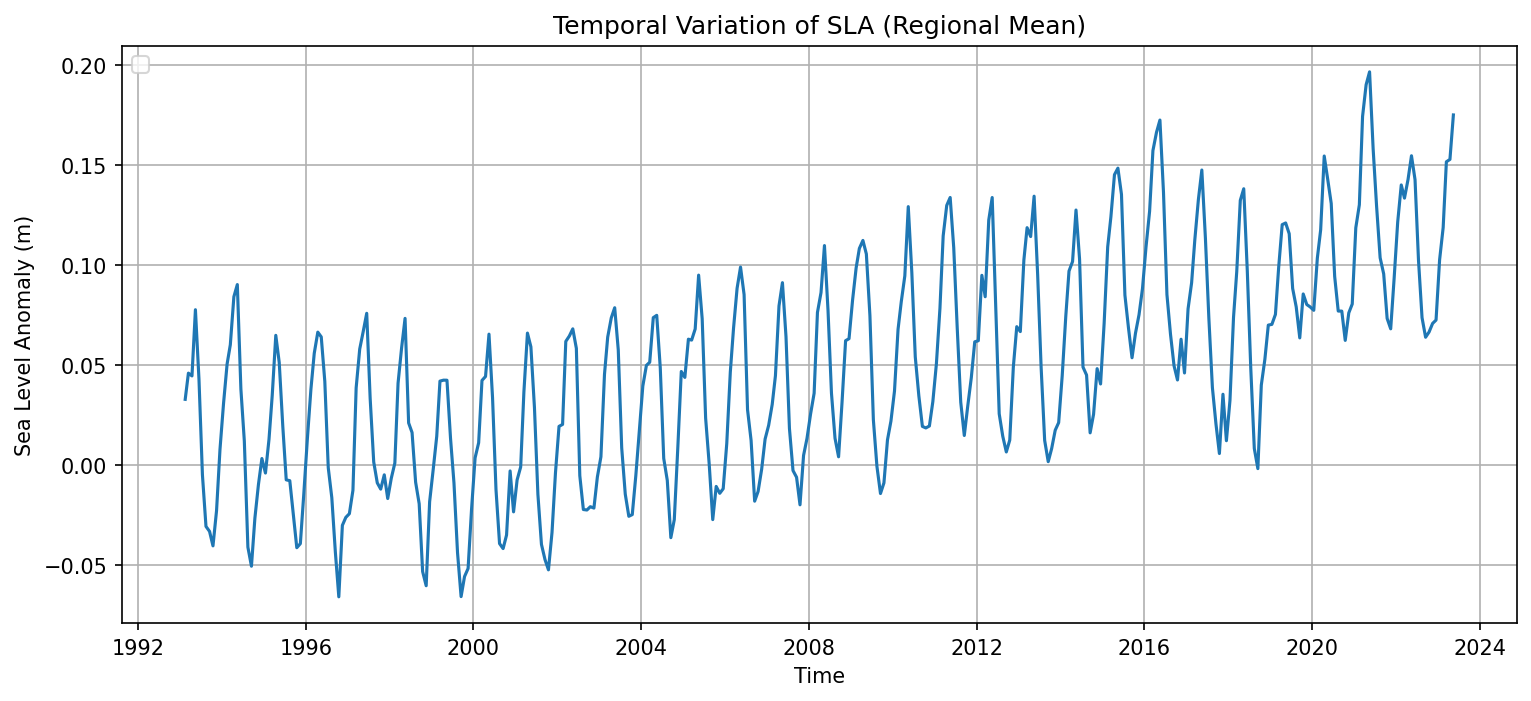

In [17]:
# 4.1 Line Plot
plt.figure(figsize=(12, 5))
plt.plot(region_mean_df['time'], region_mean_df['sla'])
plt.title('Temporal Variation of SLA (Regional Mean)')
plt.xlabel('Time')
plt.ylabel('Sea Level Anomaly (m)')
plt.legend(loc = 'upper left')
plt.grid(True)
plt.show()

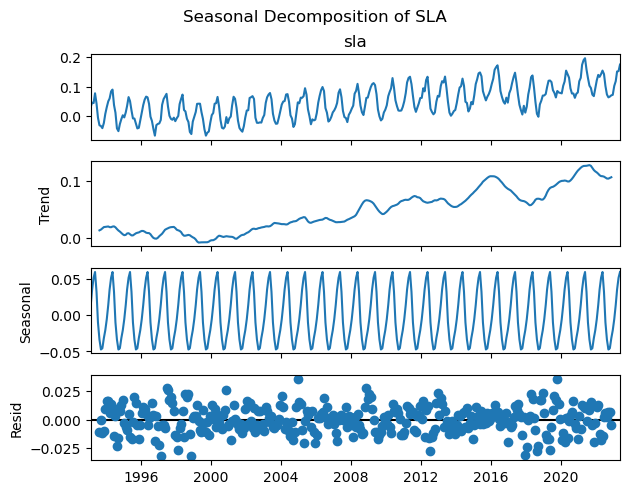

In [7]:
# 4.2 Seasonal Decomposition
region_mean_df = region_mean_df.set_index('time')
result = seasonal_decompose(region_mean_df['sla'], model='additive', period=12)
result.plot()
plt.suptitle('Seasonal Decomposition of SLA', y=1.02)
plt.show()

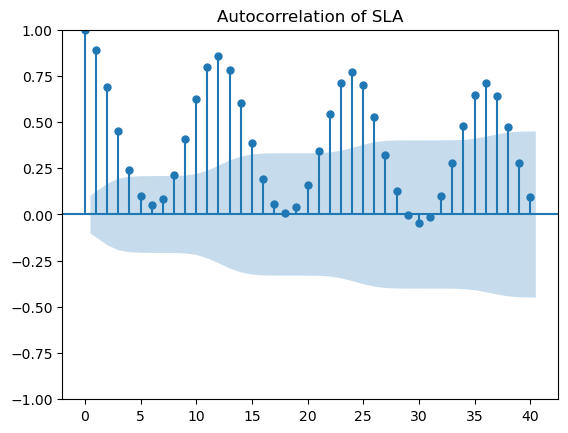

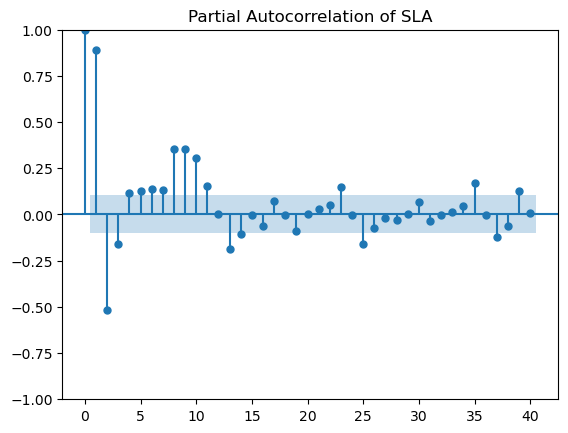

In [8]:
# 4.3 ACF and PACF
plot_acf(region_mean_df['sla'], lags=40)
plt.title("Autocorrelation of SLA")
plt.show()

plot_pacf(region_mean_df['sla'], lags=40)
plt.title("Partial Autocorrelation of SLA")
plt.show()

MAX  SLA = +0.423 m at (15.88 N, 84.12 E)
MIN  SLA = -0.213 m at (17.62 N, 86.38 E)


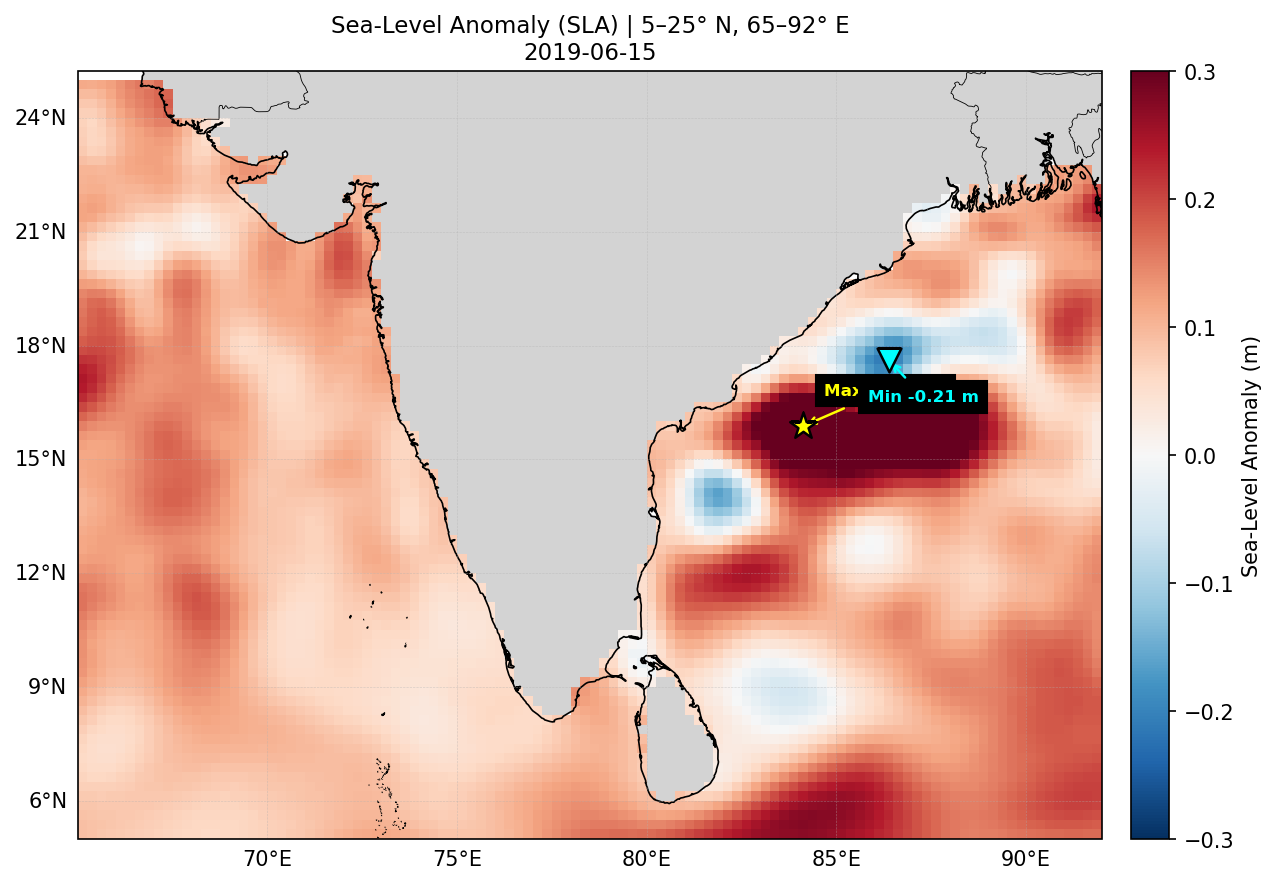

In [9]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER  # ✅ Fix: Uncommented

# ---------------------------------------------------------------
# 1.  LOAD THE NETCDF FILE  
# ---------------------------------------------------------------
nc_path = r"C:\Users\Shyam\Downloads\dt_global_satellite_sla_199302_202305.nc"
ds = xr.open_dataset(nc_path)

# ---------------------------------------------------------------
# 2.  SELECT DATE AND COASTAL WINDOW
# ---------------------------------------------------------------
target_date = np.datetime64("2019-06-01")        # choose any day in ds.time
region = ds["sla"].sel(
    latitude=slice(5, 25),                       # 5°–25° N
    longitude=slice(65, 92)                      # 65°–92° E
)
sla_snapshot = region.sel(time=target_date, method="nearest")

# ---------------------------------------------------------------
# 3.  FIND MAXIMUM AND MINIMUM SLA CELLS
# ---------------------------------------------------------------
max_row, max_col = np.unravel_index(np.nanargmax(sla_snapshot.values), sla_snapshot.shape)
min_row, min_col = np.unravel_index(np.nanargmin(sla_snapshot.values), sla_snapshot.shape)

max_lat, max_lon = float(sla_snapshot.latitude[max_row]), float(sla_snapshot.longitude[max_col])
min_lat, min_lon = float(sla_snapshot.latitude[min_row]), float(sla_snapshot.longitude[min_col])
max_val = float(sla_snapshot.values[max_row, max_col])
min_val = float(sla_snapshot.values[min_row, min_col])

print(f"MAX  SLA = {max_val:+.3f} m at ({max_lat:.2f} N, {max_lon:.2f} E)")
print(f"MIN  SLA = {min_val:+.3f} m at ({min_lat:.2f} N, {min_lon:.2f} E)")

# ---------------------------------------------------------------
# 4.  PREPARE 2‑D LONGITUDE/LATITUDE GRIDS
# ---------------------------------------------------------------
lon2d, lat2d = np.meshgrid(region.longitude, region.latitude)

# ---------------------------------------------------------------
# 5.  DRAW MAP WITH MARKERS
# ---------------------------------------------------------------
plt.rcParams.update({'figure.dpi': 150})
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add land for contrast
ax.add_feature(cfeature.LAND.with_scale("10m"), facecolor="lightgrey", zorder=0)

# Plot SLA field
pcm = ax.pcolormesh(
    lon2d, lat2d, sla_snapshot.values,
    shading="auto",
    cmap="RdBu_r", vmin=-0.3, vmax=0.3,
    transform=ccrs.PlateCarree()
)

# Mark maximum SLA (yellow star)
ax.scatter(
    max_lon, max_lat, s=180, marker="*", c="yellow", edgecolors="black",
    linewidths=1.2, transform=ccrs.PlateCarree(), zorder=5
)
ax.annotate(
    f"Max {max_val:+.2f} m",
    xy=(max_lon, max_lat), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax),
    xytext=(10, 15), textcoords="offset points",
    fontsize=8, weight="bold", color="yellow", backgroundcolor="black",
    arrowprops=dict(arrowstyle="->", color="yellow", lw=1.2)
)

# Mark minimum SLA (cyan triangle)
ax.scatter(
    min_lon, min_lat, s=130, marker="v", c="cyan", edgecolors="black",
    linewidths=1.2, transform=ccrs.PlateCarree(), zorder=5
)
ax.annotate(
    f"Min {min_val:+.2f} m",
    xy=(min_lon, min_lat), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax),
    xytext=(-10, -20), textcoords="offset points",
    fontsize=8, weight="bold", color="cyan", backgroundcolor="black",
    arrowprops=dict(arrowstyle="->", color="cyan", lw=1.2)
)

# Coastlines, borders, and gridlines
ax.coastlines("10m", lw=0.8)
ax.add_feature(cfeature.BORDERS.with_scale("10m"), lw=0.4)

# ✅ Fixed formatter usage
gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5, linestyle="--")
gl.top_labels = gl.right_labels = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

# Focus on India’s coastal band
ax.set_extent([65, 92, 5, 25])

# Color bar and title
plt.colorbar(pcm, ax=ax, pad=0.02, label="Sea‑Level Anomaly (m)")
plt.title(
    "Sea‑Level Anomaly (SLA) | 5–25° N, 65–92° E\n"
    f"{sla_snapshot['time'].dt.strftime('%Y‑%m‑%d').item()}",
    fontsize=11
)

plt.tight_layout()
plt.show()


In [10]:
# 6. Normalize / Standardize Values
# ----------------------------------------------
region_mean_df = region_mean_df.reset_index()
scaler = StandardScaler()
region_mean_df['sla_scaled'] = scaler.fit_transform(region_mean_df[['sla']])


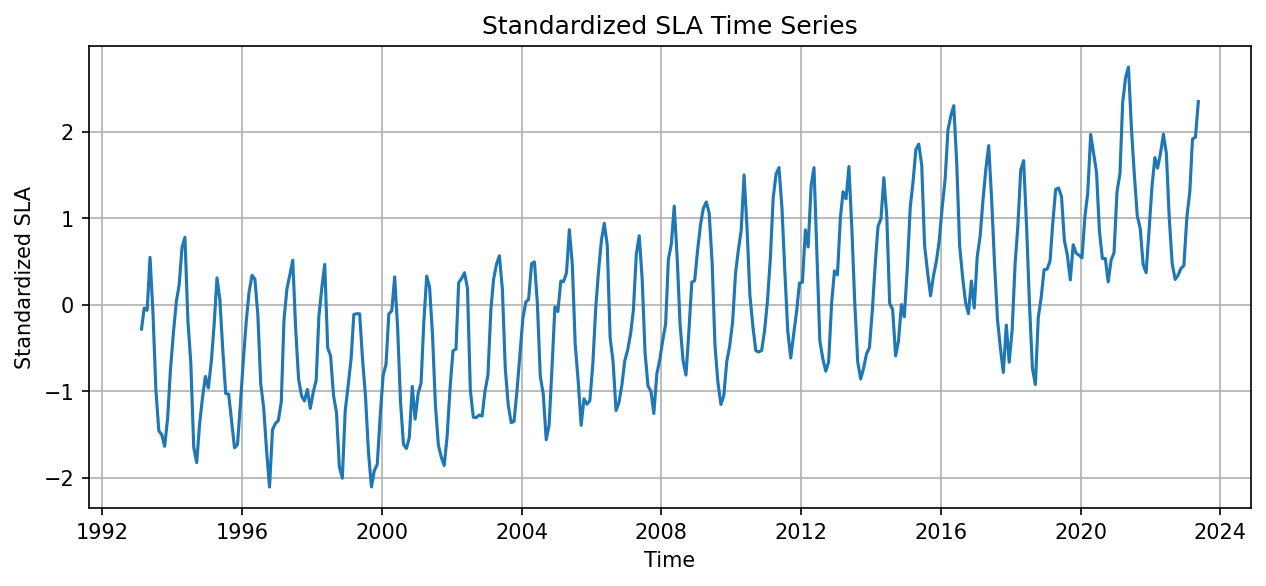

In [11]:
#7. Exploratory Data Analysis (EDA)
# ----------------------------------------------
# 7.1 Line Plot of Scaled SLA
plt.figure(figsize=(10, 4))
plt.plot(region_mean_df['time'], region_mean_df['sla_scaled'])
plt.title('Standardized SLA Time Series')
plt.xlabel('Time')
plt.ylabel('Standardized SLA')
plt.grid(True)
plt.show()


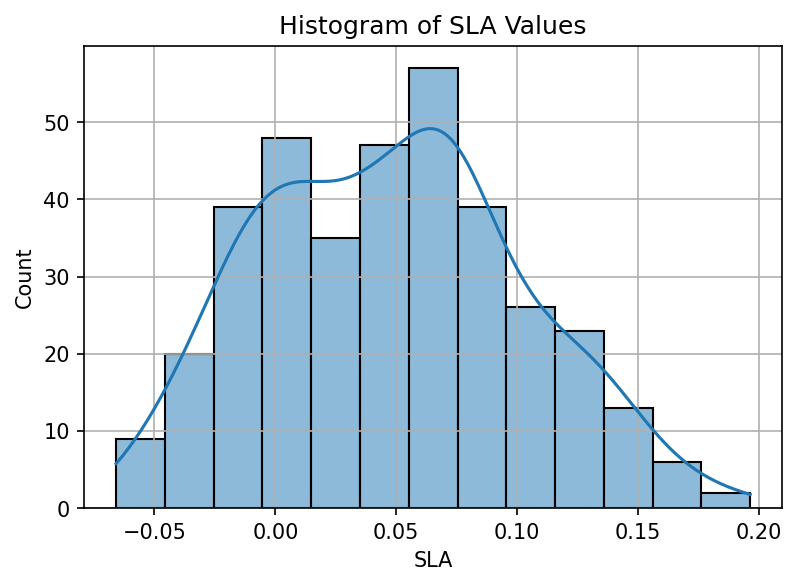

In [12]:
# 7.2 Histogram of SLA
plt.figure(figsize=(6, 4))
sns.histplot(region_mean_df['sla'], kde=True)
plt.title('Histogram of SLA Values')
plt.xlabel('SLA')
plt.grid(True)
plt.show()

In [13]:
# Final DataFrame Ready for Modeling
region_mean_df.head()

,time,sla,sla_scaled
0,1993-02-15,0.032779,-0.281113
1,1993-03-15,0.045875,-0.038373
2,1993-04-15,0.044474,-0.064333
3,1993-05-15,0.077558,0.548888
4,1993-06-15,0.042765,-0.096010
